In [128]:
from sklearn.model_selection import cross_val_score, KFold, cross_validate
from sklearn.preprocessing import PowerTransformer, RobustScaler
from sklearn.feature_selection import VarianceThreshold, RFECV, RFE
from sklearn.linear_model import LinearRegression


from ml_enhance import plot_scaled_linreg_result, CorrelationFilter


import matplotlib.pyplot as plt
from sklearn import pipeline
import seaborn as sns
import pandas as pd
import numpy as np
import scipy
import json

In [129]:
def make_pipeline(model, step_name):
    return pipeline.Pipeline([
        ("variance", VarianceThreshold(threshold=0.0)),
        ("remove_corr", CorrelationFilter(threshold=0.95)),
        ("transform", PowerTransformer(method='yeo-johnson', standardize=False)),
        ("scale", RobustScaler()),
        (step_name, model)
    ])

In [130]:
df = pd.read_csv("../data/processed_dataset_wo_metals_w_more_qm.csv")

df = df.drop("avg_atomic_quadrupole_principal_invariant_3", axis=1)

y = df["solubility"]
X = df.drop(["solubility", "smiles", "canon_smiles", "id"], axis=1)

In [131]:
with open("../data/rdkit_feature_names.json", "r") as f:
    rdkit_feature_list: list = json.load(f)

mask = X.columns.isin(rdkit_feature_list)

In [132]:
X_topo = X.iloc[:, mask]
X_qm = X.iloc[:, ~mask]

In [133]:
X_qm.columns

Index(['energy', 'atomization_energy', 'homo_lumo_gap', 'ionization_energy',
       'electron_affinity', 'chemical_potential', 'molecular_dipole_norm',
       'molecular_quadrupole_principal_invariant_2',
       'molecular_quadrupole_principal_invariant_3',
       'molecular_polarizability_mean',
       ...
       'avg_overlap_integral', 'min_overlap_integral', 'max_overlap_integral',
       'avg_bond_energy', 'min_bond_energy', 'max_bond_energy',
       'avg_atomic_dipole_dipole_interaction',
       'min_atomic_dipole_dipole_interaction',
       'max_atomic_dipole_dipole_interaction', 'num_heavy_H_bonds'],
      dtype='str', length=104)

In [134]:
pl_linear = make_pipeline(LinearRegression(), "predict")

In [135]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [96]:
scoring = {
    "r2": "r2",
    "MSE": "neg_mean_squared_error"
}

In [97]:
scores_combo = cross_validate(pl_linear, X, y, cv=cv, scoring=scoring, n_jobs=4, return_estimator=True, return_train_score=True)

In [98]:
scores_topo = cross_validate(pl_linear, X_topo, y, cv=cv, scoring=scoring, n_jobs=4, return_estimator=True, return_train_score=True)

In [99]:

scores_qm = cross_validate(pl_linear, X_qm, y, cv=cv, scoring=scoring, n_jobs=4, return_estimator=True, return_train_score=True)

In [100]:
print(f"Train scores:\nTopology alone: {scores_topo["train_r2"].mean()}\nQM alone: {scores_qm["train_r2"].mean()}\nCombined: {scores_combo["train_r2"].mean()}")
print("\n")
print(f"Test scores:\nTopology alone: {scores_topo["test_r2"].mean()}\nQM alone: {scores_qm["test_r2"].mean()}\nCombined: {scores_combo["test_r2"].mean()}")

Train scores:
Topology alone: 0.8293075247616226
QM alone: 0.7253579017997284
Combined: 0.8411060708970732


Test scores:
Topology alone: 0.8173806995189228
QM alone: 0.6985552684478966
Combined: 0.8170391450908138


For the linear regression, the QM descriptors alone seem to give the worst performance out of the three, but **there seems to be no significant difference between the topological descriptors alone and the combined feature set**. This can mean three things, the QM descriptors provide no advantage because:
- due to the larger dataset (desired outcome)
- They are not so useful for solubility predictions
- The linear model cannot benefit from using them (in one way or another) 

Lets try and make a RFE to see whether the QM descriptors do in fact provide any value to the linear model.

In [101]:
rfe_pipe = make_pipeline(RFECV(LinearRegression(), cv=cv, scoring="r2", n_jobs=4), "rfe")

rfe_pipe.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('variance', ...), ('remove_corr', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0.0
,threshold,0.95
,"method method: {'yeo-johnson', 'box-cox'}, default='yeo-johnson'The power transform method. Available methods are:- 'yeo-johnson' [1]_, works with positive and negative values- 'box-cox' [2]_, only works with strictly positive values",'yeo-johnson'
,"standardize standardize: bool, default=TrueSet to True to apply zero-mean, unit-variance normalization to thetransformed output.",False
,"copy copy: bool, default=TrueSet to False to perform inplace computation during transformation.",True
,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_scaling with_scaling: bool, default=TrueIf `True`, scale the data to interquartile range.",True


In [104]:
filtered_features = rfe_pipe.get_feature_names_out()
X_rfe = X[filtered_features]
X_rfe.info()

<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Columns: 179 entries, energy to fr_urea
dtypes: float64(89), int64(90)
memory usage: 12.0 MB


In these 227 remaining features, I am curious how many QM features are still left. 

In [105]:
with open("../data/properties.json", "r") as f:
    data = json.load(f)

qm_feature_names = [feature["name_of_property"] for feature in data]

In [107]:
scores_post_rfe = cross_validate(pl_linear, X_rfe, y, cv=cv, scoring=scoring, n_jobs=4, return_estimator=True, return_train_score=True)

In [108]:
train_score_pre_rfe = scores_combo["train_r2"].mean()
test_score_pre_rfe = scores_combo["test_r2"].mean()
print(f"Pre-RFE:\nTrain score : {train_score_pre_rfe}\nTest score: {test_score_pre_rfe}\nDifference: {abs(test_score_pre_rfe - train_score_pre_rfe)}")

print("\n")

train_score_rfe = scores_post_rfe['train_r2'].mean()
test_score_rfe = scores_post_rfe['test_r2'].mean()
print(f"Post-RFE:\nTrain score : {train_score_rfe}\nTest score: {test_score_rfe}\nDifference: {abs(test_score_rfe - train_score_rfe)}")

Pre-RFE:
Train score : 0.8411060708970732
Test score: 0.8170391450908138
Difference: 0.024066925806259465


Post-RFE:
Train score : 0.839796740340673
Test score: 0.8299042898878138
Difference: 0.009892450452859136


The difference between the test and train score actually improved because of the RFE, meaning it is a better fit

In [109]:
best_post_rfe_pl = scores_post_rfe["estimator"][2]
best_pre_rfe_pl = scores_combo["estimator"][1]

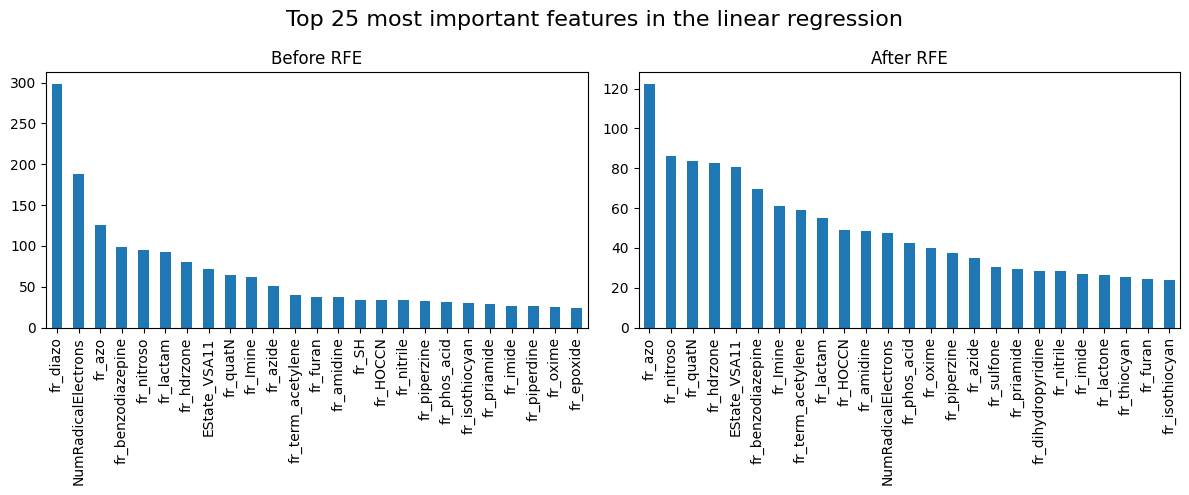

In [113]:
pre_rfe_importance = pd.Series(
    best_pre_rfe_pl.named_steps["predict"].coef_,
    index=best_pre_rfe_pl[:-1].get_feature_names_out()
    )

post_rfe_importance = pd.Series(
    best_post_rfe_pl.named_steps["predict"].coef_,
    index=best_post_rfe_pl[:-1].get_feature_names_out()
    )

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

pre_rfe_importance.abs().sort_values(ascending=False)[:25].plot.bar(ax=ax[0])
ax[0].set_title("Before RFE")

post_rfe_importance.abs().sort_values(ascending=False)[:25].plot.bar(ax=ax[1])
ax[1].set_title("After RFE")

plt.suptitle("Top 25 most important features in the linear regression", fontsize=16)
plt.tight_layout()
plt.show()

In [114]:
qm_remaining_features = X_rfe.columns[X_rfe.columns.isin(qm_feature_names)]
print(len(qm_remaining_features))
post_rfe_importance[qm_remaining_features]

11


energy                                -2.097661
homo_lumo_gap                         -0.100214
ionization_energy                     -0.243377
electron_affinity                     -0.093383
chemical_potential                     0.138322
molecular_dipole_norm                  0.182032
molecular_polarizability_mean          0.259496
molecular_polarizability_anisotropy    0.025400
enthalpy                              -0.238757
radius_of_gyration                    -0.560664
solvation_energy_water                 0.096058
dtype: float64

In [123]:
len(qm_remaining_features)

11

In [125]:
tot_cols = len(X_rfe.columns)
fr_cols = len(X_rfe.filter(regex="fr_").columns)
qm_cols = len(qm_remaining_features)
print(f"Fraction of 'fr_' features remaining in the dataset: {fr_cols / tot_cols}")
print(f"Fraction of QM features remaining in the dataset: {qm_cols / tot_cols}")

Fraction of 'fr_' features remaining in the dataset: 0.4134078212290503
Fraction of QM features remaining in the dataset: 0.061452513966480445


I think a major problem of the dataset is that the amount of QM features is way less than the amount of topological features. A lot of the QM features are highly correlated and are removed, while the 'fr_' features are quite dominant. 